In [13]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results
from stable_baselines3.common import results_plotter

from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize


In [ ]:
# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([5.0, 0.05])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high), c_r_RH (RH), c_r_co2_vent (CO2+vent), c_coact (heat+vent action)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4,  # u1, u2, u3
                           0.5,                             # c_r_co2_1
                           0.6, 0.3,                        # c_r_T1, c_r_T2
                           0.05,                            # c_r_RH
                           0.001, 0.06])                     # c_r_co2_vent, c_coact


weather_file = root_dir + r"\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat"

base_env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs,
    n_days= 40
)
log_dir = 'tmp'
os.makedirs(log_dir, exist_ok=True)
env = Monitor(base_env, log_dir)

vec_env = DummyVecEnv([lambda: env])
train_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.)

In [30]:

# Initialize the Soft Actor-Critic
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SAC("MlpPolicy", train_env, verbose=1, learning_rate=1e-3, batch_size=64, device='cpu')
model.learn(total_timesteps=40000, progress_bar=True, log_interval=10) 
model.save("sac_lettuce_greenhouse")

Output()

Using cpu device


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 3.84e+03  |
|    ep_rew_mean     | -1.68e+04 |
| time/              |           |
|    episodes        | 10        |
|    fps             | 87        |
|    time_elapsed    | 438       |
|    total_timesteps | 38400     |
| train/             |           |
|    actor_loss      | 366       |
|    critic_loss     | 22.8      |
|    ent_coef        | 0.0795    |
|    ent_coef_loss   | -0.9      |
|    learning_rate   | 0.001     |
|    n_updates       | 38299     |
----------------------------------


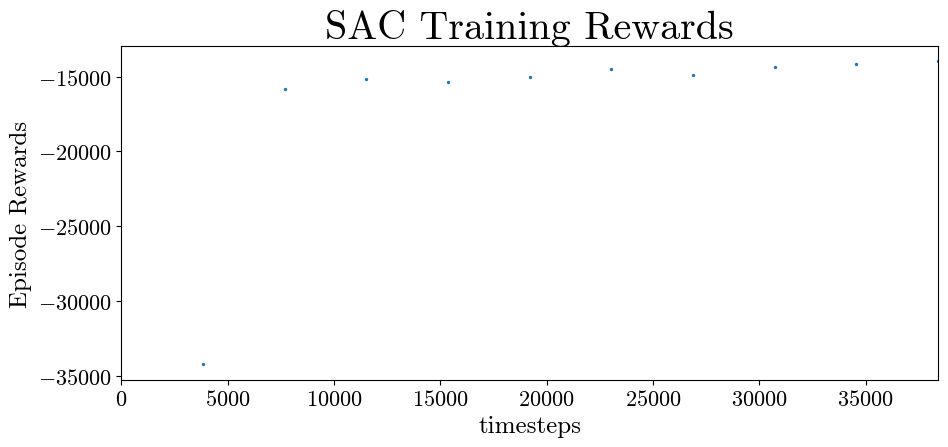

In [32]:
#plot the rewards from the training

results_plotter.plot_results([log_dir], 40000, results_plotter.X_TIMESTEPS, "SAC Training Rewards", figsize=(10,5))


In [33]:
from aml_project.common.helper_functions import weather2ppmrh

print("Starting evaluation...")

# Reset the wrapped environment
obs = train_env.reset() 

N_steps = base_env.N
ny = base_env.ny
action_dim = base_env.action_space.shape[0]

y = np.zeros((N_steps + 1, ny))
u = np.zeros((N_steps, action_dim))
rewards = np.zeros((N_steps, 1))

# 2. unnormalized initial observation from the wrapper
y[0] = train_env.get_original_obs()[0][:ny]
base_env.prev_action = np.zeros(action_dim)

k = 0
done = False 

while not done and k < N_steps:
    action, _states = model.predict(obs, deterministic=True)
    
    # Step the environment
    obs, reward, dones, infos = train_env.step(action)
    done = dones[0]

    u[k] = base_env.prev_action
    
    # unnormalized physical observation for this step
    unnormalized_obs = train_env.get_original_obs()
    y[k+1] = unnormalized_obs[0][:ny] 

    rewards[k] += reward[0]
    k += 1

y = y[:k]
d = weather2ppmrh(base_env.d[:k])
u = u[:k]
r = rewards[:k]

print(f"Evaluation complete. Total Reward: {np.sum(r):.2f}")

Starting evaluation...
Evaluation complete. Total Reward: -13394.13


Plotting results...


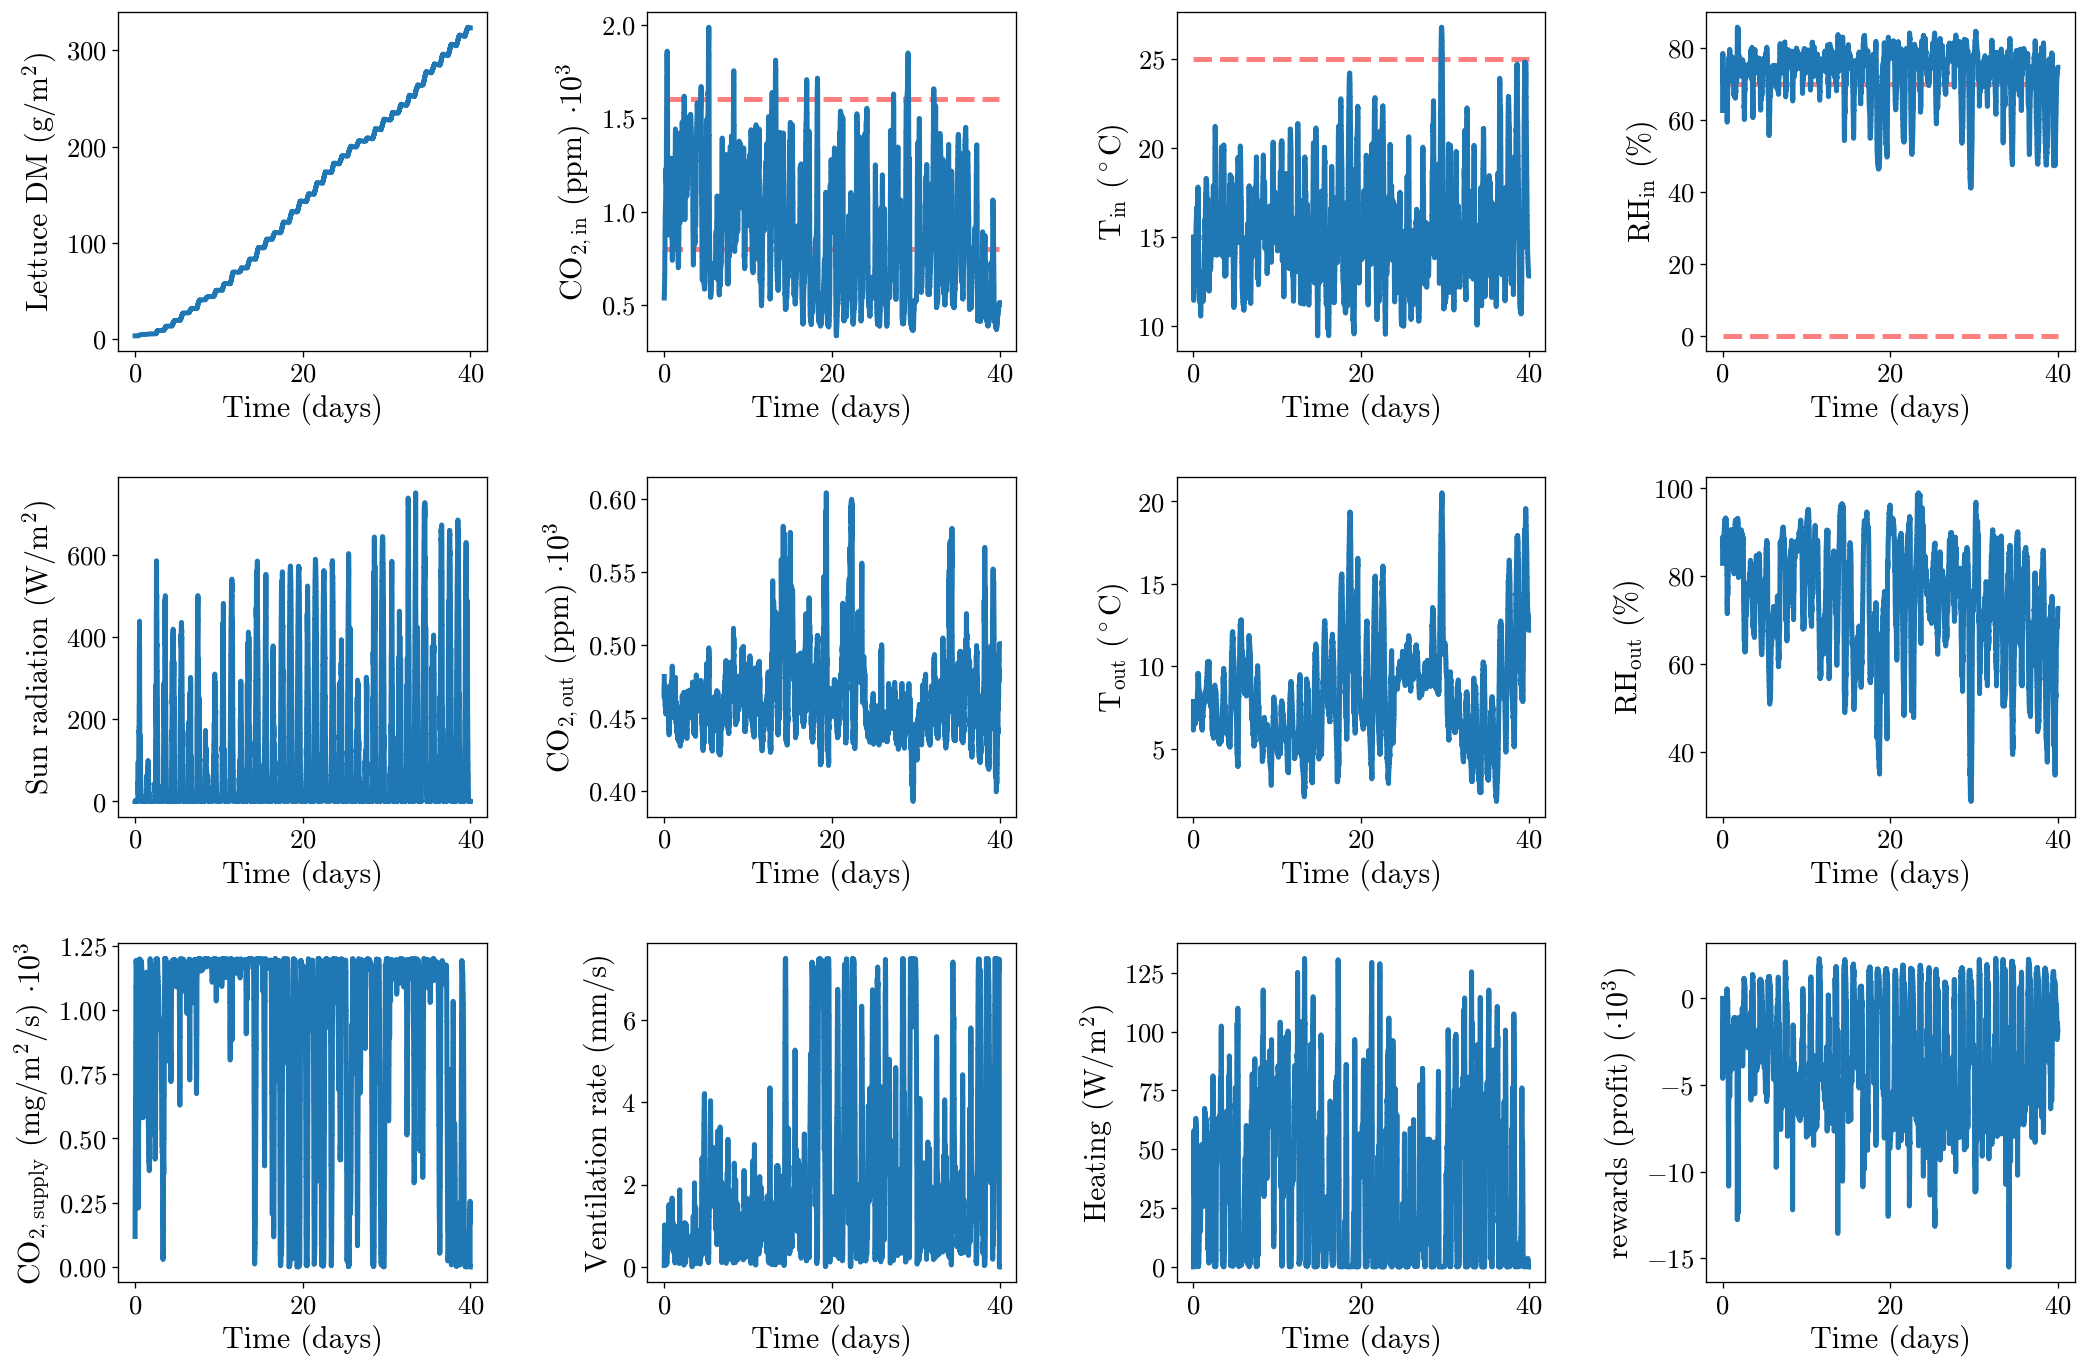

In [34]:
print("Plotting results...")

nvars = 12
n_per_day = int((24 * 3600) / base_env.h) 
label = 'Trained SAC policy'
trajectory = np.concatenate((y, d, u, r), axis=1)
fig, axes = create_trajectory_figure(nvars, base_env.L, base_env.h, base_env.c, base_env.obs_low, base_env.obs_high)
fig, axes = plot_trajectory(fig, axes, trajectory, base_env.L, base_env.h, base_env.c, 0, base_env.n_days, n_per_day, label)

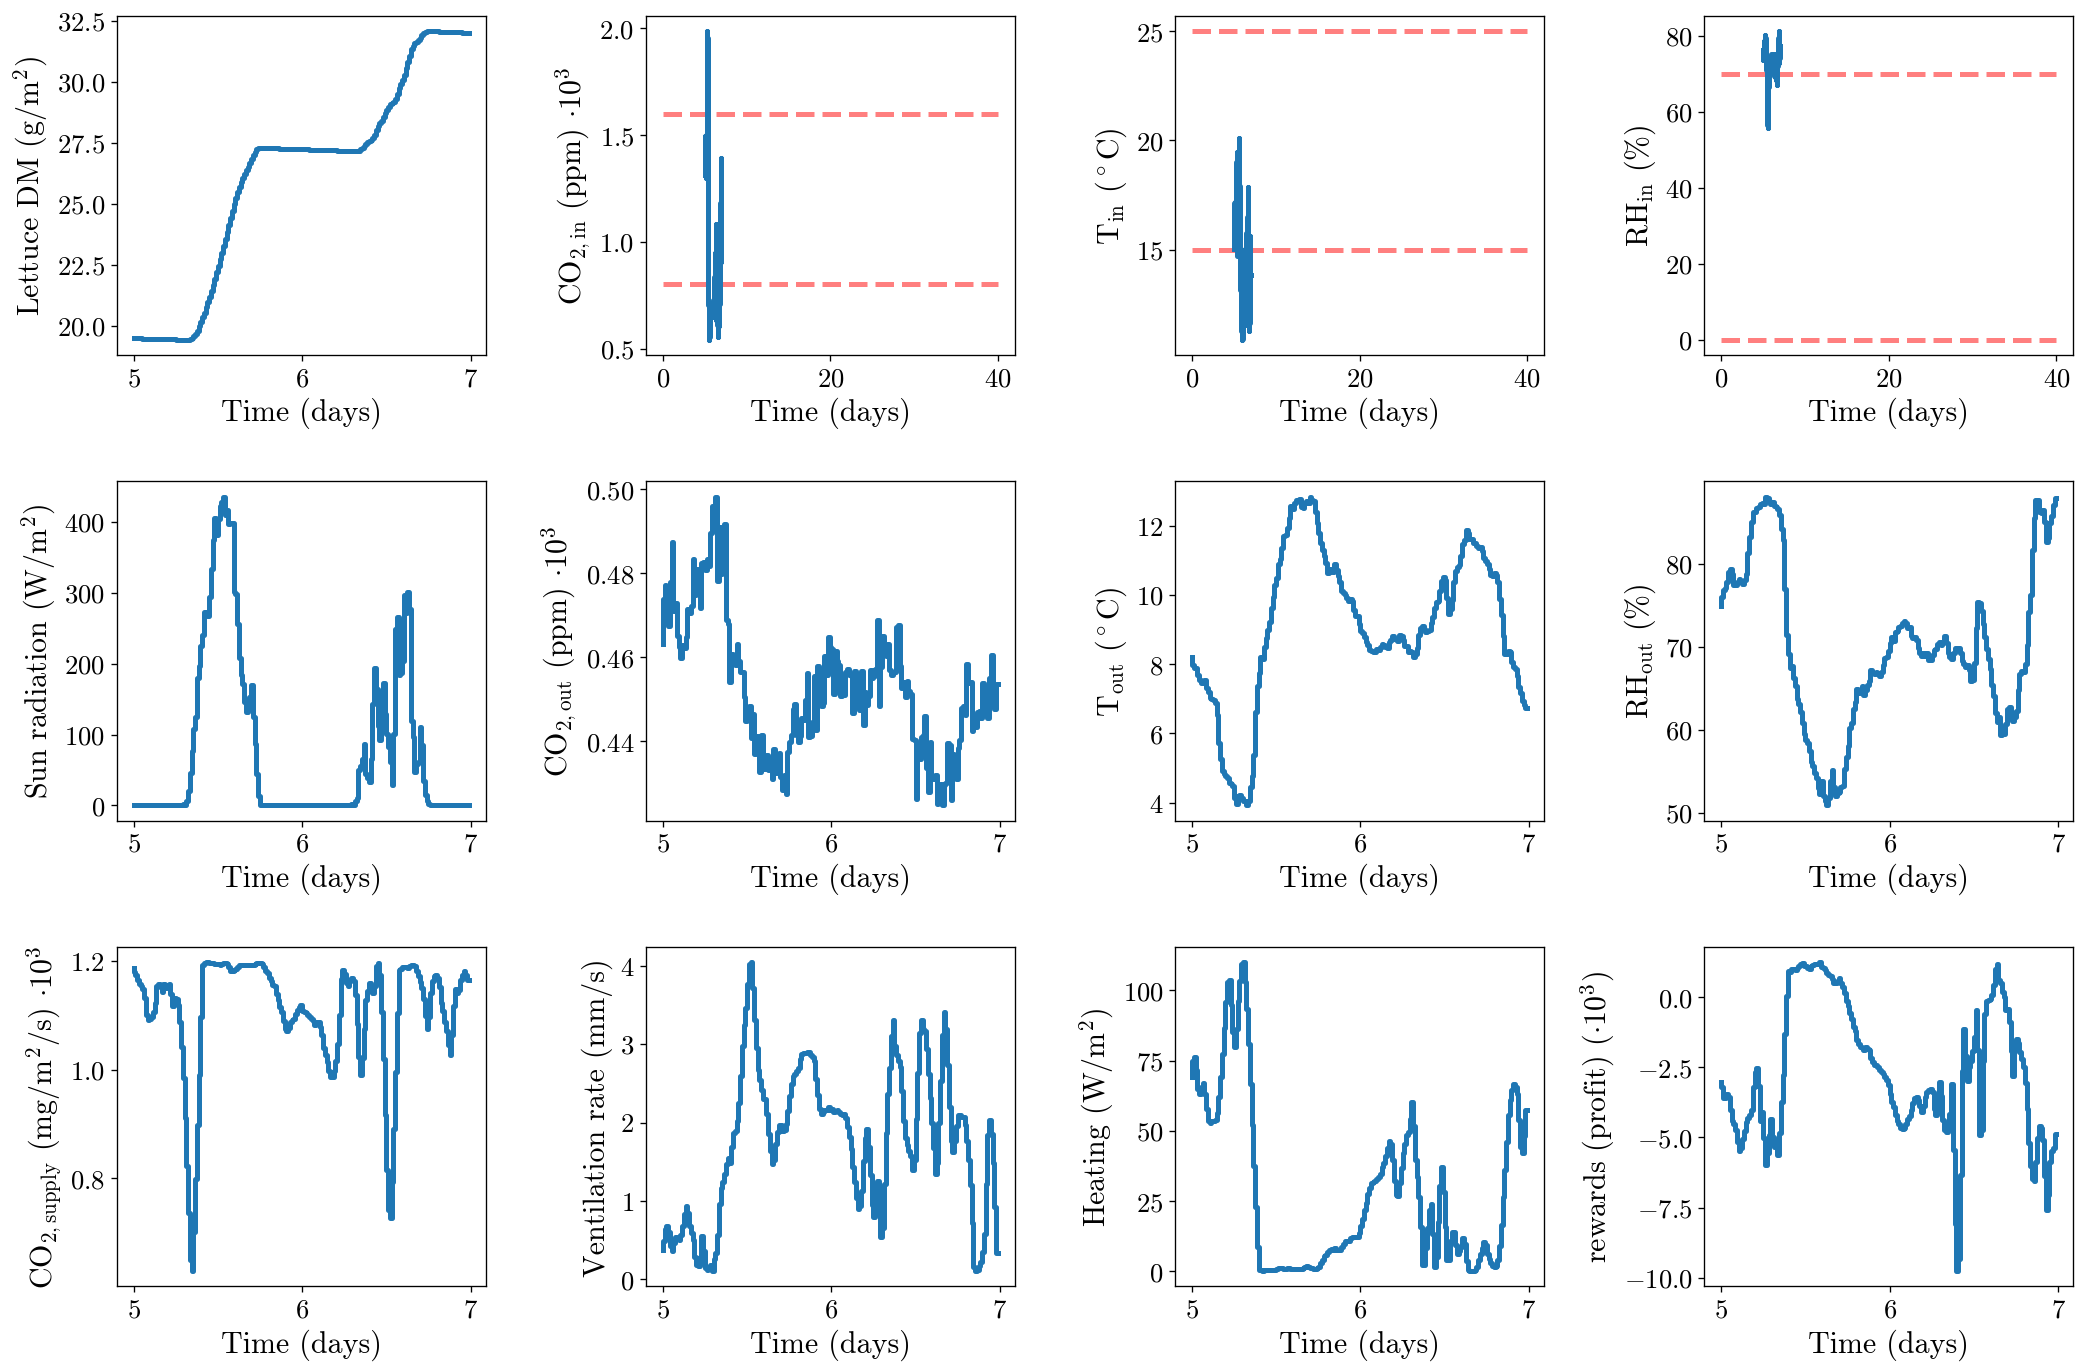

In [35]:
# Change 'env' to 'base_env' so the plotting function can see your greenhouse dimensions
fig, axes = create_trajectory_figure(
    nvars, 
    base_env.L, 
    base_env.h, 
    base_env.c, 
    base_env.obs_low,  # It's better to pass your actual bounds here instead of None!
    base_env.obs_high  # (Or leave as None, None if your function specifically handles it)
)

fig, axes = plot_trajectory(
    fig, 
    axes, 
    trajectory, 
    base_env.L, 
    base_env.h, 
    base_env.c, 
    5,           # Start day (make sure this matches your intended slice!)
    2,            # Number of days to plot
    n_per_day, 
    label
)

In [36]:
def run_zero_input_baseline(base_env):
    # Use base_env to get standard 5-variable gym outputs
    obs, info = base_env.reset()
    terminated = False
    truncated = False
    
    # Action space is scaled between -1 and 1. -1 corresponds to 0 physical input.
    zero_action = np.array([-1.0, -1.0, -1.0], dtype=np.float32) 
    
    # We must check BOTH terminated and truncated for standard Gymnasium loops
    while not terminated and not truncated:
        obs, reward, terminated, truncated, info = base_env.step(zero_action)
        
    # Assuming info['profit'] holds a cumulative array or scalar at the end
    return info['profit'].sum(), info


def run_heuristic_baseline(base_env):
    # Use base_env so the raw physics (ppm, celsius) match your 'if' statements
    obs, info = base_env.reset()
    terminated = False
    truncated = False
    
    while not terminated and not truncated:
        # obs[:4] corresponds to raw greenhouse measurements: [dry_weight, co2_ppm, temp_c, rh]
        co2_ppm = obs[1]
        temp_c = obs[2]
        
        # CO2 Dosing 
        co2_act = 0.2 if co2_ppm < 850 else -1.0
        
        # Temperature 
        if temp_c < 16.0:
            heat_act = 0.5  # Turn on heating
            vent_act = -1.0 # Close vents to trap heat
        elif temp_c > 19.5:
            heat_act = -1.0 # Turn off heating
            vent_act = 0.3  # Open vents to cool down
        else:
            heat_act = -1.0 # Optimal band: do nothing
            vent_act = -1.0
            
        action = np.array([co2_act, vent_act, heat_act], dtype=np.float32)
        
        # Standard 5-item unpack
        obs, reward, terminated, truncated, info = base_env.step(action)
        
    return info['profit'].sum(), info

In [37]:

sac_total_profit = infos[0]['profit'].sum()

zero_profit, zero_info = run_zero_input_baseline(base_env)
heuristic_profit, heuristic_info = run_heuristic_baseline(base_env)

print(f"Zero Input Profit          : {zero_profit:.2f}")
print(f"Heuristic Baseline Profit  : {heuristic_profit:.2f}")
print(f"Trained SAC Agent Profit   : {sac_total_profit:.2f}")

Zero Input Profit          : 368.72
Heuristic Baseline Profit  : 2075.67
Trained SAC Agent Profit   : 1478.10
